# Fake News Classifier - Model Training
## Part 2: Training and Model Comparison

### 1. Import Libraries

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

### 2. Load and Preprocess Data

In [78]:
df = pd.read_csv('fake_and_real_news.csv')

print(f"Dataset loaded: {len(df):,} articles")
print(f"Label distribution:\n{df['label'].value_counts()}")

Dataset loaded: 9,900 articles
Label distribution:
label
Fake    5000
Real    4900
Name: count, dtype: int64


In [79]:
# Text preprocessing function
def preprocess_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    text = ' '.join(text.split())

    return text

print("Preprocessing text...")
df['cleaned_text'] = df['Text'].apply(preprocess_text)

print("\nExample of preprocessing:")
print("Original:", df['Text'].iloc[0][:200])
print("\nCleaned:", df['cleaned_text'].iloc[0][:200])

Preprocessing text...

Example of preprocessing:
Original:  Top Trump Surrogate BRUTALLY Stabs Him In The Back: ‘He’s Pathetic’ (VIDEO) It s looking as though Republican presidential candidate Donald Trump is losing support even from within his own ranks. You

Cleaned: top trump surrogate brutally stabs him in the back hes pathetic video it s looking as though republican presidential candidate donald trump is losing support even from within his own ranks you know th


In [80]:
X = df['cleaned_text']
y = df['label']

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\nTarget classes: {y.unique()}")

Features (X): (9900,)
Target (y): (9900,)

Target classes: ['Fake' 'Real']


### 3. Train/Test Split

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train/Test Split:")
print(f"  Training set: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test set: {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nTraining set label distribution:")
print(y_train.value_counts())

print(f"\nTest set label distribution:")
print(y_test.value_counts())

Train/Test Split:
  Training set: 7,920 samples (80.0%)
  Test set: 1,980 samples (20.0%)

Training set label distribution:
label
Fake    4000
Real    3920
Name: count, dtype: int64

Test set label distribution:
label
Fake    1000
Real     980
Name: count, dtype: int64


### 4. TF-IDF Vectorization

In [82]:
stop_words = stopwords.words('english')

tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words=stop_words,
    ngram_range=(1, 2),
    min_df=2
)

print("TF-IDF Vectorizer Configuration:")
print(f"  Max features: 10000")
print(f"  N-gram range: (1, 2)")
print(f"  Stopwords: {len(stop_words)} English stopwords")
print(f"  Min document frequency: 2")

TF-IDF Vectorizer Configuration:
  Max features: 10000
  N-gram range: (1, 2)
  Stopwords: 198 English stopwords
  Min document frequency: 2


### 5. Model Training

In [83]:
# Dictionary to store results
results = {}

print("="*60)
print("TRAINING MODELS")
print("="*60)

TRAINING MODELS


#### 5.1 Multinomial Naive Bayes

In [84]:
print("\n[1] Training Multinomial Naive Bayes...")

# Create pipeline
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, stop_words=stop_words, ngram_range=(1, 2), min_df=2)),
    ('classifier', MultinomialNB())
])

# Train model
nb_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_nb = nb_pipeline.predict(X_test)

# Calculate metrics
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb, pos_label='Fake', average='weighted')
nb_recall = recall_score(y_test, y_pred_nb, pos_label='Fake', average='weighted')
nb_f1 = f1_score(y_test, y_pred_nb, pos_label='Fake', average='weighted')

# Store results
results['Multinomial Naive Bayes'] = {
    'pipeline': nb_pipeline,
    'predictions': y_pred_nb,
    'accuracy': nb_accuracy,
    'precision': nb_precision,
    'recall': nb_recall,
    'f1_score': nb_f1
}

print(f"\n  Accuracy: {nb_accuracy:.4f}")
print(f"  Precision: {nb_precision:.4f}")
print(f"  Recall: {nb_recall:.4f}")
print(f"  F1-Score: {nb_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))


[1] Training Multinomial Naive Bayes...

  Accuracy: 0.9737
  Precision: 0.9738
  Recall: 0.9737
  F1-Score: 0.9737

Classification Report:
              precision    recall  f1-score   support

        Fake       0.97      0.98      0.97      1000
        Real       0.98      0.97      0.97       980

    accuracy                           0.97      1980
   macro avg       0.97      0.97      0.97      1980
weighted avg       0.97      0.97      0.97      1980



#### 5.2 Logistic Regression

In [85]:
print("\n[2] Training Logistic Regression...")

# Create pipeline
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, stop_words=stop_words, ngram_range=(1, 2), min_df=2)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Train model
lr_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_pipeline.predict(X_test)

# Calculate metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, pos_label='Fake', average='weighted')
lr_recall = recall_score(y_test, y_pred_lr, pos_label='Fake', average='weighted')
lr_f1 = f1_score(y_test, y_pred_lr, pos_label='Fake', average='weighted')

# Store results
results['Logistic Regression'] = {
    'pipeline': lr_pipeline,
    'predictions': y_pred_lr,
    'accuracy': lr_accuracy,
    'precision': lr_precision,
    'recall': lr_recall,
    'f1_score': lr_f1
}

print(f"\n  Accuracy: {lr_accuracy:.4f}")
print(f"  Precision: {lr_precision:.4f}")
print(f"  Recall: {lr_recall:.4f}")
print(f"  F1-Score: {lr_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


[2] Training Logistic Regression...

  Accuracy: 0.9924
  Precision: 0.9924
  Recall: 0.9924
  F1-Score: 0.9924

Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      1000
        Real       0.99      0.99      0.99       980

    accuracy                           0.99      1980
   macro avg       0.99      0.99      0.99      1980
weighted avg       0.99      0.99      0.99      1980



### 6. Model Comparison

In [86]:
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1_score'] for m in results.keys()]
})

print("MODEL COMPARISON")
print(comparison_df.to_string(index=False))


MODEL COMPARISON
                  Model  Accuracy  Precision   Recall  F1-Score
Multinomial Naive Bayes  0.973737   0.973828 0.973737  0.973734
    Logistic Regression  0.992424   0.992425 0.992424  0.992424


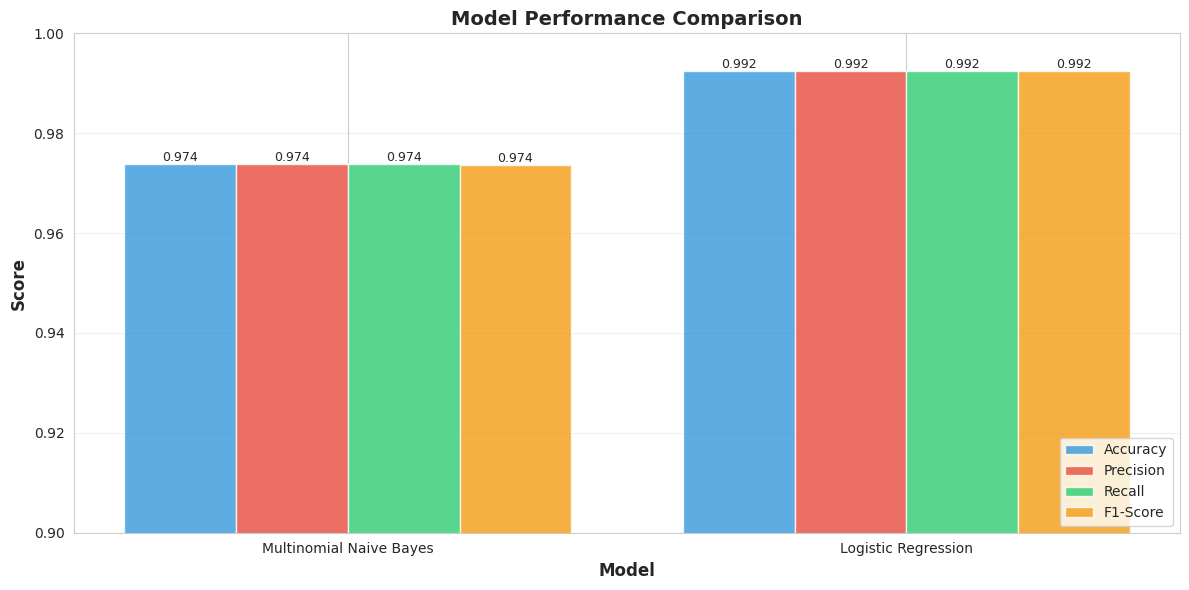

In [87]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison_df))
width = 0.2

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    offset = width * (i - 1.5)
    bars = ax.bar(x + offset, comparison_df[metric], width, label=metric, color=color, alpha=0.8)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'])
ax.legend(loc='lower right')
ax.set_ylim([0.9, 1.0])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 7. Confusion Matrices

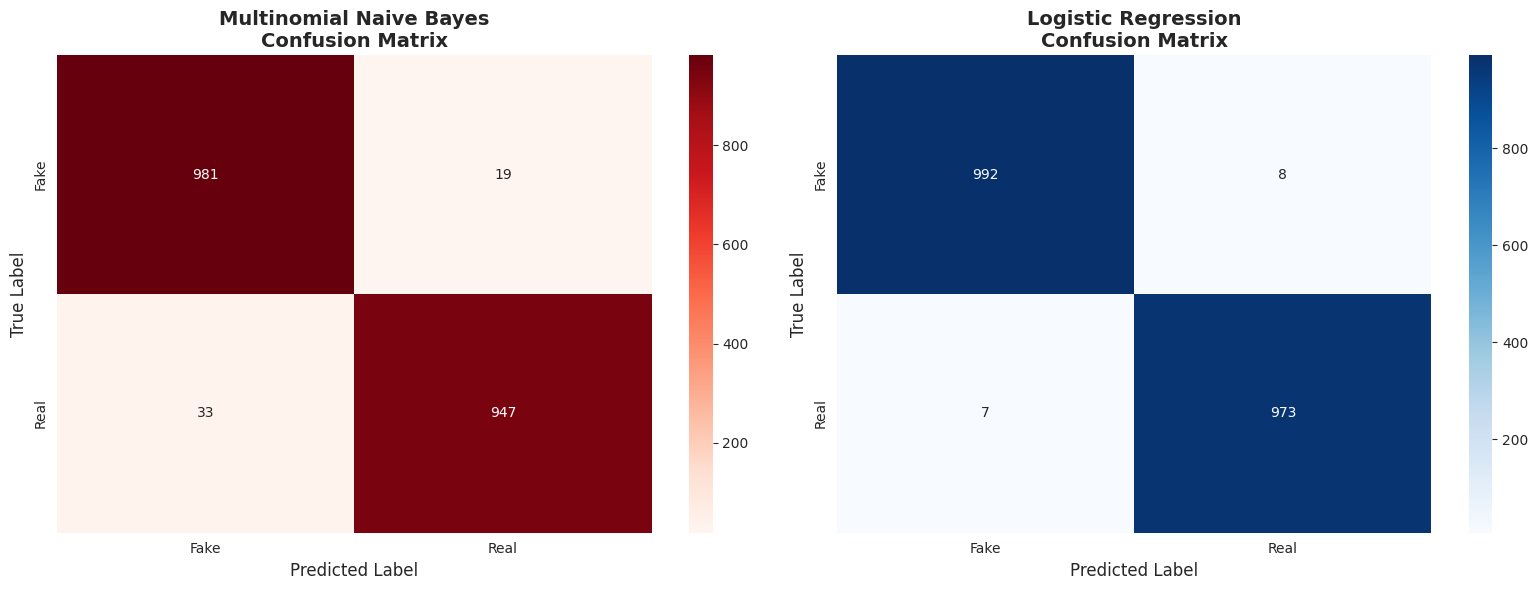

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Multinomial Naive Bayes
cm_nb = confusion_matrix(y_test, results['Multinomial Naive Bayes']['predictions'], labels=['Fake', 'Real'])
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
axes[0].set_title('Multinomial Naive Bayes\nConfusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Logistic Regression
cm_lr = confusion_matrix(y_test, results['Logistic Regression']['predictions'], labels=['Fake', 'Real'])
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
axes[1].set_title('Logistic Regression\nConfusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()

### 8. Select Best Model

In [89]:
# Select best model based on F1-Score
best_model_name = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
best_model_pipeline = results[best_model_name]['pipeline']
best_accuracy = results[best_model_name]['accuracy']
best_f1 = results[best_model_name]['f1_score']

print("BEST MODEL SELECTION")
print(f"\nBest Model: {best_model_name}")
print(f"Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"F1-Score: {best_f1:.4f}")

print(f"\nWhy this model?")
if best_model_name == 'Logistic Regression':
    print("- Logistic Regression outperforms Naive Bayes")
    print("- Does not assume feature independence (unlike Naive Bayes)")
    print("- Better handles correlated features in text data")
    print("- Provides probability estimates for predictions")
else:
    print("- Multinomial Naive Bayes is efficient and fast")
    print("- Works well with text classification tasks")
    print("- Requires less training time")

BEST MODEL SELECTION

Best Model: Logistic Regression
Accuracy: 0.9924 (99.24%)
F1-Score: 0.9924

Why this model?
- Logistic Regression outperforms Naive Bayes
- Does not assume feature independence (unlike Naive Bayes)
- Better handles correlated features in text data
- Provides probability estimates for predictions


### 9. Save Best Model

In [90]:
model_path = 'models/best_model.pkl'
joblib.dump(best_model_pipeline, model_path)

print(f"\nBest model saved to: {model_path}")
print(f"  Model: {best_model_name}")
print(f"  Accuracy: {best_accuracy:.4f}")
print(f"  F1-Score: {best_f1:.4f}")

loaded_model = joblib.load(model_path)
print("\nModel loaded successfully!")

test_text = "Breaking news: Scientists discover new planet in our solar system!"
prediction = loaded_model.predict([test_text])[0]
probabilities = loaded_model.predict_proba([test_text])[0]

print("\nTest Prediction:")
print(f"  Text: '{test_text}'")
print(f"  Prediction: {prediction}")
print(f"  Confidence: Fake={probabilities[0]:.2%}, Real={probabilities[1]:.2%}")


Best model saved to: models/best_model.pkl
  Model: Logistic Regression
  Accuracy: 0.9924
  F1-Score: 0.9924

Model loaded successfully!

Test Prediction:
  Text: 'Breaking news: Scientists discover new planet in our solar system!'
  Prediction: Fake
  Confidence: Fake=62.68%, Real=37.32%


### 10. Final Summary

In [91]:
print("TRAINING SUMMARY")

print(f"\n1. Dataset:")
print(f"   - Total samples: {len(df):,}")
print(f"   - Training: {len(X_train):,} | Test: {len(X_test):,}")

print(f"\n2. Preprocessing:")
print(f"   - Lowercasing")
print(f"   - Punctuation removal")
print(f"   - Stopword removal")
print(f"   - TF-IDF vectorization (max_features=10000)")

print(f"\n3. Models Trained:")
for model_name in results.keys():
    acc = results[model_name]['accuracy']
    f1 = results[model_name]['f1_score']
    print(f"   - {model_name}: Accuracy={acc:.4f}, F1={f1:.4f}")

print(f"\n4. Best Model:")
print(f"   - Model: {best_model_name}")
print(f"   - Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"   - F1-Score: {best_f1:.4f}")
print(f"   - Saved to: {model_path}")

TRAINING SUMMARY

1. Dataset:
   - Total samples: 9,900
   - Training: 7,920 | Test: 1,980

2. Preprocessing:
   - Lowercasing
   - Punctuation removal
   - Stopword removal
   - TF-IDF vectorization (max_features=10000)

3. Models Trained:
   - Multinomial Naive Bayes: Accuracy=0.9737, F1=0.9737
   - Logistic Regression: Accuracy=0.9924, F1=0.9924

4. Best Model:
   - Model: Logistic Regression
   - Accuracy: 0.9924 (99.24%)
   - F1-Score: 0.9924
   - Saved to: models/best_model.pkl
